In [170]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [171]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


### Задача 1. Различия по городам

In [172]:
pay_user = df.groupby(['id_user','city']).agg({'mon':'count',
                                              'cnt_indiv':'sum',
                                              'cnt_total':'sum',
                                              'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'}) 
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,СПб,9,33,33,58600
1,1001,Москва,11,23,129,124800
2,1002,Москва,11,64,128,166000
3,1004,Екатеринбург,9,18,18,32000
4,1005,СПб,2,7,7,12600


In [173]:
pay_user['avg_check_per_month'] = pay_user['sum_total']/pay_user['nmonths']

In [174]:
pay_user['share_indiv'] = pay_user['cnt_indiv']/pay_user['cnt_total']

In [175]:
pay_user.head()

,id_user,city,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_month,share_indiv
0,1000,СПб,9,33,33,58600,6511.111111,1.000000
1,1001,Москва,11,23,129,124800,11345.454545,0.178295
2,1002,Москва,11,64,128,166000,15090.909091,0.500000
3,1004,Екатеринбург,9,18,18,32000,3555.555556,1.000000
4,1005,СПб,2,7,7,12600,6300.000000,1.000000


In [176]:
city_stats = pay_user.groupby('city').agg({'id_user':'nunique',
                                          'avg_check_per_month':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'nuser'})
city_stats.head()

,city,nuser,avg_check_per_month,share_indiv
0,Екатеринбург,128,6735.819862,0.308108
1,Казань,127,6698.701412,0.247886
2,Москва,310,7194.958013,0.654638
3,СПб,273,7123.468912,0.333030


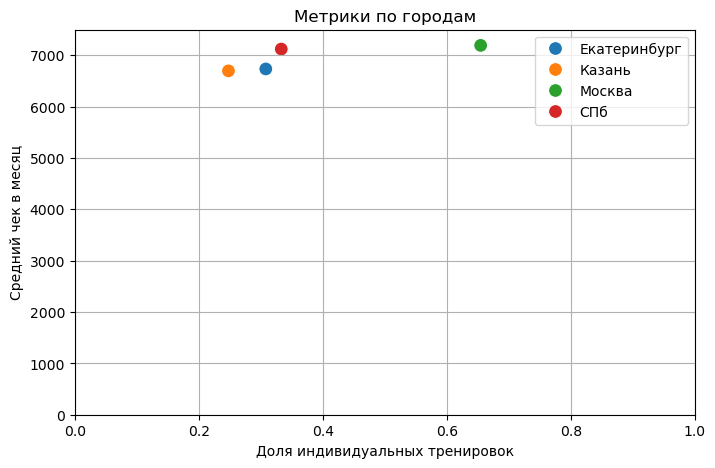

In [177]:
plt.figure(figsize=(8,5))
plt.xlim(0,1)
plt.ylim(0,7500)
sns.scatterplot(data = city_stats, x = 'share_indiv', y = 'avg_check_per_month',hue = 'city', s = 100)
plt.xlabel('Доля индивидуальных тренировок')
plt.ylabel('Средний чек в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid()
plt.show()

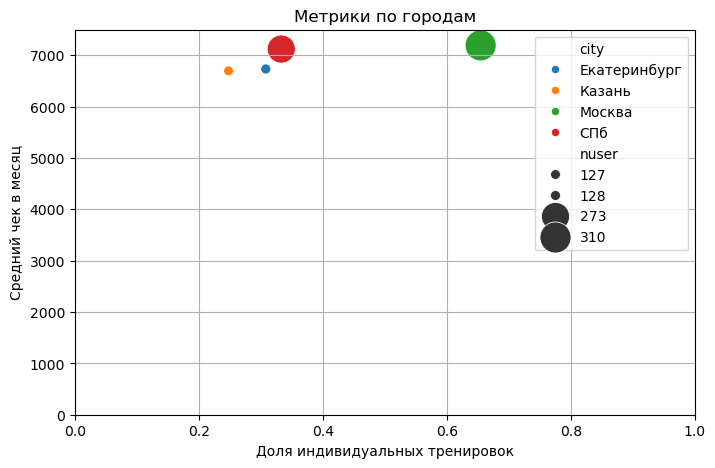

In [178]:
plt.figure(figsize=(8,5))
plt.xlim(0,1)
plt.ylim(0,7500)
sns.scatterplot(data = city_stats,
                x = 'share_indiv',
                y = 'avg_check_per_month',
                hue = 'city',
                size = 'nuser',
                sizes = (50,500))
plt.xlabel('Доля индивидуальных тренировок')
plt.ylabel('Средний чек в месяц')
plt.title('Метрики по городам')
plt.legend()
plt.grid()
plt.show()

### Задача 2. сравнение по возрастным когортам

In [179]:
def age_group(age):
    if age <= 30:
        return '18-30'
    elif age>=31 and age<=45:
        return '31-45'
    else:
        return '46+'

In [180]:
df['age_gr'] = df['age'].apply(age_group)
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31-45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45


In [181]:
age_user = df.groupby(['id_user','age_gr']).agg({'mon':'count',
                                              'cnt_indiv':'sum',
                                              'cnt_total':'sum',
                                              'sum_total':'sum'}).reset_index().rename(columns = {'mon':'nmonths'}) 
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total
0,1000,31-45,9,33,33,58600
1,1001,31-45,11,23,129,124800
2,1002,31-45,11,64,128,166000
3,1004,46+,9,18,18,32000
4,1005,31-45,2,7,7,12600


In [182]:
age_user['avg_check_per_month'] = age_user['sum_total']/age_user['nmonths']

In [183]:
age_user['share_indiv'] = age_user['cnt_indiv']/age_user['cnt_total']

In [184]:
age_user['avg_train_per_month'] = age_user['cnt_total']/age_user['nmonths']

In [185]:
age_user.head()

,id_user,age_gr,nmonths,cnt_indiv,cnt_total,sum_total,avg_check_per_month,share_indiv,avg_train_per_month
0,1000,31-45,9,33,33,58600,6511.111111,1.000000,3.666667
1,1001,31-45,11,23,129,124800,11345.454545,0.178295,11.727273
2,1002,31-45,11,64,128,166000,15090.909091,0.500000,11.636364
3,1004,46+,9,18,18,32000,3555.555556,1.000000,2.000000
4,1005,31-45,2,7,7,12600,6300.000000,1.000000,3.500000


In [186]:
age_segm = age_user.groupby('age_gr').agg({'id_user':'nunique',
                                           'nmonths':'mean',
                                          'avg_check_per_month':'mean',
                                          'avg_train_per_month':'mean',
                                          'share_indiv':'mean'}).reset_index().rename(columns = {'id_user':'nusers'})
age_segm

,age_gr,nusers,nmonths,avg_check_per_month,avg_train_per_month,share_indiv
0,18-30,278,5.399281,8222.747802,7.290366,0.446690
1,31-45,271,5.343173,7774.985357,7.003930,0.445543
2,46+,289,5.681661,5173.422485,4.737098,0.414714


### Задача 3. Топ-10 пользователей по LTR

In [187]:
df_gr = df.groupby('id_user').agg({'sum_total':'sum'}).reset_index().sort_values('sum_total',ascending=False).head(10)

In [188]:
df_gr

,id_user,sum_total
2,1002,166000
551,1657,164200
319,1381,147600
135,1153,147400
420,1506,146400
27,1029,140000
12,1013,139800
485,1582,136200
446,1536,134400
402,1482,131400


In [189]:
user_lst = df_gr['id_user'].tolist()
user_lst

[1002, 1657, 1381, 1153, 1506, 1029, 1013, 1582, 1536, 1482]

In [190]:
df_top = df[df['id_user'].isin(user_lst)]
df_top

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
20,1002,2023-02,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
21,1002,2023-03,4,8,3200,14400,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
22,1002,2023-04,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45
23,1002,2023-05,2,10,1600,16000,12,17600,2023-02,2023-12,Москва,34.0,male,31-45
24,1002,2023-06,7,4,5600,7200,11,12800,2023-02,2023-12,Москва,34.0,male,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3098,1657,2023-06,12,2,9600,3600,14,13200,2023-01,2023-11,СПб,27.0,male,18-30
3099,1657,2023-08,9,5,7200,9000,14,16200,2023-01,2023-11,СПб,27.0,male,18-30
3100,1657,2023-09,11,3,8800,5400,14,14200,2023-01,2023-11,СПб,27.0,male,18-30
3101,1657,2023-10,12,2,9600,3600,14,13200,2023-01,2023-11,СПб,27.0,male,18-30


In [191]:
user_top = df_top.groupby(['id_user','city','gender','age_gr']).agg({'mon':'count',
                                                                      'cnt_total':'sum',
                                                                       'sum_total':'sum'
                                                                       }).reset_index().rename(columns = ({'mon':'nmonths'}))

In [192]:
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total
0,1002,Москва,male,31-45,11,128,166000
1,1013,Москва,male,31-45,11,151,139800
2,1029,СПб,female,31-45,8,126,140000
3,1153,СПб,male,46+,12,118,147400
4,1381,Москва,female,18-30,12,159,147600
5,1482,Москва,female,18-30,11,110,131400
6,1506,Москва,female,18-30,10,138,146400
7,1536,Москва,female,18-30,9,125,134400
8,1582,Екатеринбург,male,31-45,8,127,136200
9,1657,СПб,male,18-30,10,144,164200


In [193]:
user_top['avg_check_per_month'] = user_top['sum_total']/user_top['nmonths']

In [194]:
user_top['avg_train_per_month'] = user_top['cnt_total']/user_top['nmonths']

In [195]:
user_top

,id_user,city,gender,age_gr,nmonths,cnt_total,sum_total,avg_check_per_month,avg_train_per_month
0,1002,Москва,male,31-45,11,128,166000,15090.909091,11.636364
1,1013,Москва,male,31-45,11,151,139800,12709.090909,13.727273
2,1029,СПб,female,31-45,8,126,140000,17500.000000,15.750000
3,1153,СПб,male,46+,12,118,147400,12283.333333,9.833333
4,1381,Москва,female,18-30,12,159,147600,12300.000000,13.250000
5,1482,Москва,female,18-30,11,110,131400,11945.454545,10.000000
6,1506,Москва,female,18-30,10,138,146400,14640.000000,13.800000
7,1536,Москва,female,18-30,9,125,134400,14933.333333,13.888889
8,1582,Екатеринбург,male,31-45,8,127,136200,17025.000000,15.875000
9,1657,СПб,male,18-30,10,144,164200,16420.000000,14.400000


In [196]:
user_top['city'].value_counts()

city
Москва          6
СПб             3
Екатеринбург    1
Name: count, dtype: int64

In [197]:
user_top['gender'].value_counts()

gender
male      5
female    5
Name: count, dtype: int64

In [198]:
user_top['age_gr'].value_counts()

age_gr
18-30    5
31-45    4
46+      1
Name: count, dtype: int64

### Задача 4. Анализ доходимости когорт

In [199]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female,31-45
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female,31-45
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female,31-45


In [200]:
df.dtypes

id_user        int64
mon           object
cnt_group      int64
cnt_indiv      int64
sum_group      int64
sum_indiv      int64
cnt_total      int64
sum_total      int64
min_mon       object
max_mon       object
city          object
age          float64
gender        object
age_gr        object
dtype: object

In [201]:
df['mon'] = pd.to_datetime(df['mon'], format = '%Y-%m')
df['min_mon'] = pd.to_datetime(df['min_mon'], format = '%Y-%m')

In [202]:
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45


In [203]:
df['cohort_index'] = df['mon'].dt.month - df['min_mon'].dt.month
df.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender,age_gr,cohort_index
0,1000,2023-03-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,0
1,1000,2023-04-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,1
2,1000,2023-05-01,0,4,0,6400,4,6400,2023-03-01,2023-12,СПб,44.0,female,31-45,2
3,1000,2023-06-01,0,2,0,3600,2,3600,2023-03-01,2023-12,СПб,44.0,female,31-45,3
4,1000,2023-07-01,0,4,0,7200,4,7200,2023-03-01,2023-12,СПб,44.0,female,31-45,4


In [204]:
cohort_stats = df.groupby(['min_mon','cohort_index']).agg(active_users=('id_user','count')).reset_index()

In [205]:
cohort_stats

,min_mon,cohort_index,active_users
0,2023-01-01,0,337
1,2023-01-01,1,262
2,2023-01-01,2,205
3,2023-01-01,3,168
4,2023-01-01,4,159
...,...,...,...
73,2023-10-01,1,16
74,2023-10-01,2,15
75,2023-11-01,0,10
76,2023-11-01,1,7


In [206]:
cohort_size = cohort_stats[cohort_stats['cohort_index']==0][['min_mon','active_users']].rename(columns={'active_users':'cohsize'})

In [207]:
cohort_data = cohort_stats.merge(cohort_size, on = 'min_mon')
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize
0,2023-01-01,0,337,337
1,2023-01-01,1,262,337
2,2023-01-01,2,205,337
3,2023-01-01,3,168,337
4,2023-01-01,4,159,337


In [208]:
cohort_data['retention'] = cohort_data['active_users']/cohort_data['cohsize']
cohort_data.head()

,min_mon,cohort_index,active_users,cohsize,retention
0,2023-01-01,0,337,337,1.000000
1,2023-01-01,1,262,337,0.777448
2,2023-01-01,2,205,337,0.608309
3,2023-01-01,3,168,337,0.498516
4,2023-01-01,4,159,337,0.471810


In [209]:
retention_table = pd.pivot_table(cohort_data,
                                index = 'min_mon',
                                columns = 'cohort_index',
                                values = 'retention')
retention_table

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11
min_mon,,,,,,,,,,,,
2023-01-01,1.0,0.777448,0.608309,0.498516,0.471810,0.454006,0.489614,0.465875,0.448071,0.483680,0.451039,0.397626
2023-02-01,1.0,0.761364,0.602273,0.568182,0.579545,0.522727,0.522727,0.545455,0.522727,0.443182,0.431818,NaN
2023-03-01,1.0,0.746988,0.590361,0.578313,0.542169,0.506024,0.481928,0.493976,0.469880,0.481928,NaN,NaN
2023-04-01,1.0,0.725806,0.645161,0.548387,0.564516,0.580645,0.548387,0.435484,0.419355,NaN,NaN,NaN
2023-05-01,1.0,0.701754,0.561404,0.614035,0.614035,0.614035,0.578947,0.315789,NaN,NaN,NaN,NaN
2023-06-01,1.0,0.823529,0.705882,0.549020,0.470588,0.490196,0.411765,NaN,NaN,NaN,NaN,NaN
2023-07-01,1.0,0.770833,0.666667,0.666667,0.625000,0.437500,NaN,NaN,NaN,NaN,NaN,NaN
2023-08-01,1.0,0.885714,0.571429,0.400000,0.342857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-01,1.0,0.678571,0.500000,0.464286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [210]:
retention_table.index = retention_table.index.strftime('%Y-%m')

In [211]:
retention_table.iloc[:,:4]

cohort_index,0,1,2,3
min_mon,,,,
2023-01,1.0,0.777448,0.608309,0.498516
2023-02,1.0,0.761364,0.602273,0.568182
2023-03,1.0,0.746988,0.590361,0.578313
2023-04,1.0,0.725806,0.645161,0.548387
2023-05,1.0,0.701754,0.561404,0.614035
2023-06,1.0,0.823529,0.705882,0.549020
2023-07,1.0,0.770833,0.666667,0.666667
2023-08,1.0,0.885714,0.571429,0.400000
2023-09,1.0,0.678571,0.500000,0.464286


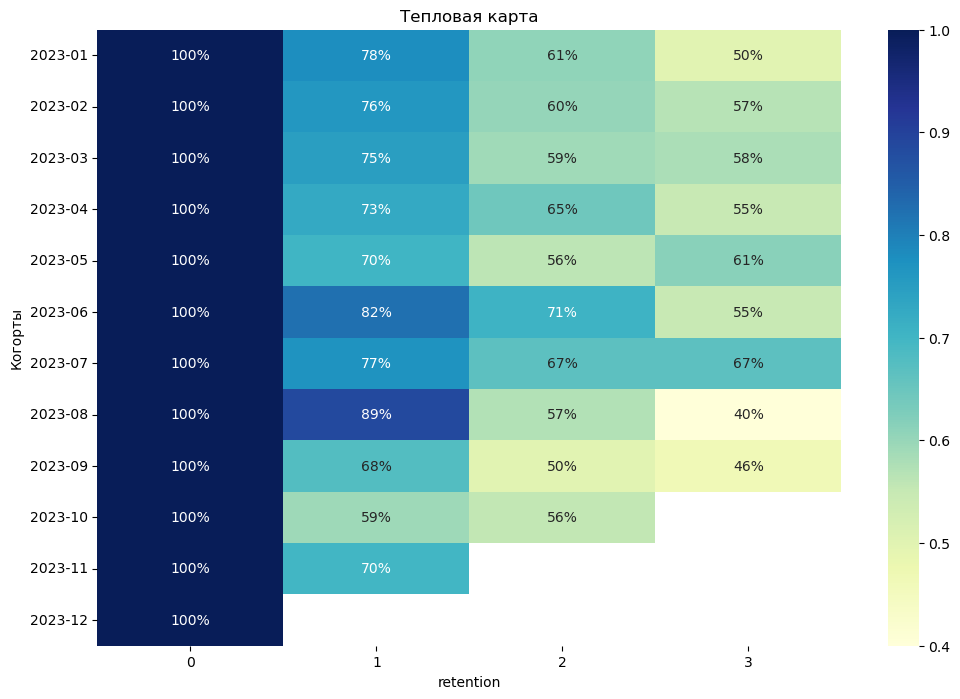

In [212]:
plt.figure(figsize=(12,8))
sns.heatmap(retention_table.iloc[:,:4],annot = True, fmt = '.0%',cmap='YlGnBu')
plt.xlabel('retention')
plt.ylabel('Когорты')
plt.title('Тепловая карта')
plt.show()